# ForgeWM — Experiment 2 (CLEAN)
## Unknown Constitutive Recovery — Toner-Tu Active Matter

**All previous fixes consolidated. Run cells top to bottom.**

### What this recovers
True equation: `rho * (a - b*|v|²) * |v|`  (Toner-Tu active term)
Axiom system A: standard Navier-Stokes (no active term)
Method: residual-guided sampling → PySR on anomaly region

### Drive structure
All outputs → `MyDrive/ForgeWM_E2/`
df_rich (5000 samples, 20 features) already on Drive from previous session.

---

## Cell 1 — Mount Drive + Install + Restore State

In [1]:
# ── Mount Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Install packages ─────────────────────────────────────────────────
import subprocess
subprocess.run('pip install -q ripser persim pysr', shell=True)

# ── Imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import json, pickle, os, time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Drive paths ───────────────────────────────────────────────────────
DRIVE_ROOT    = '/content/drive/MyDrive/ForgeWM_E2'
CKPT_FEM      = f'{DRIVE_ROOT}/checkpoints/fem_samples'
CKPT_TDA      = f'{DRIVE_ROOT}/checkpoints/tda'
CKPT_PYSR     = f'{DRIVE_ROOT}/checkpoints/pysr'
CKPT_BASELINE = f'{DRIVE_ROOT}/checkpoints/baselines'
RESULTS_DIR   = f'{DRIVE_ROOT}/results'
FIGURES_DIR   = f'{DRIVE_ROOT}/figures'
for d in [CKPT_FEM,CKPT_TDA,CKPT_PYSR,
          CKPT_BASELINE,RESULTS_DIR,FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Checkpoint manager ────────────────────────────────────────────────
class CheckpointManager:
    def __init__(self, d):
        self.dir = d
        self.meta_path = f'{d}/meta.json'
    def get_progress(self):
        if os.path.exists(self.meta_path):
            with open(self.meta_path) as f:
                return json.load(f).get('n_completed', 0)
        return 0
    def load_all(self):
        files = sorted(Path(self.dir).glob('batch_*.pkl'))
        if not files: return pd.DataFrame()
        return pd.concat([pd.read_pickle(str(f)) for f in files],
                         ignore_index=True)
    def save_batch(self, df_b, idx):
        df_b.to_pickle(f'{self.dir}/batch_{idx:05d}.pkl')
        n = self.get_progress() + len(df_b)
        with open(self.meta_path,'w') as f:
            json.dump({'n_completed':n,'last_batch':idx,
                       'timestamp':time.strftime('%Y-%m-%d %H:%M:%S')},f)
    def save_artifact(self, obj, name):
        with open(f'{self.dir}/{name}.pkl','wb') as f: pickle.dump(obj,f)
    def load_artifact(self, name):
        p = f'{self.dir}/{name}.pkl'
        if os.path.exists(p):
            with open(p,'rb') as f: return pickle.load(f)
        return None

ckpt_fem       = CheckpointManager(CKPT_FEM)
ckpt_tda       = CheckpointManager(CKPT_TDA)
ckpt_pysr      = CheckpointManager(CKPT_PYSR)
ckpt_baselines = CheckpointManager(CKPT_BASELINE)

# ── Load df_rich from Drive ───────────────────────────────────────────
rich_path = f'{CKPT_FEM}/df_rich.pkl'
if os.path.exists(rich_path):
    df_full = pd.read_pickle(rich_path)
    print(f'df_rich loaded from Drive: {df_full.shape} ✓')
else:
    # Fallback: load from batch files
    df_full = ckpt_fem.load_all()
    print(f'df_full loaded from batches: {df_full.shape}')
    print('WARNING: df_rich not found — run Cell 2 to regenerate')

# ── Verify packages ───────────────────────────────────────────────────
import ripser, persim
from pysr import PySRRegressor
print('ripser ✓  persim ✓  pysr ✓')

# ── Status ────────────────────────────────────────────────────────────
print('\nDrive artifact status:')
for label, ckpt, name in [
    ('void_region',       ckpt_tda,       'void_region'),
    ('pysr_model',        ckpt_pysr,      'pysr_model'),
    ('baseline_results',  ckpt_baselines, 'baseline_results'),
]:
    a = ckpt.load_artifact(name)
    print(f'  {label}: {"✓ cached" if a is not None else "— needs computing"}')

Mounted at /content/drive
df_rich loaded from Drive: (5000, 20) ✓
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https

## Cell 2 — Simulation Functions (always run)

In [2]:
# ── Parameter ranges ─────────────────────────────────────────────────
am_param_ranges = {
    'a':      (0.1,  2.0),
    'b':      (0.1,  3.0),
    'eta':    (0.01, 0.5),
    'lambda': (0.5,  2.0),
    'D':      (0.01, 0.2),
}

def sample_am_params(rng):
    return {k: rng.uniform(lo, hi)
            for k, (lo, hi) in am_param_ranges.items()}

def active_matter_sample(params, n_grid=32, n_steps=200, dt=0.005):
    """
    Toner-Tu active matter simulation.
    200 timesteps — sufficient for statistics to converge.
    Returns 20-feature dict including v_mag^2 statistics.
    """
    a   = params['a']
    b   = params['b']
    eta = params['eta']
    D   = params['D']

    rng = np.random.default_rng(seed=int(abs(a*b*1e4)) % 2**31)
    rho = 1.0 + 0.1 * rng.standard_normal((n_grid, n_grid))
    vx  = 0.5 * rng.standard_normal((n_grid, n_grid))
    vy  = 0.5 * rng.standard_normal((n_grid, n_grid))

    for _ in range(n_steps):
        v_mag_sq = vx**2 + vy**2
        ax = (a - b*v_mag_sq)*rho*vx
        ay = (a - b*v_mag_sq)*rho*vy
        lx = (np.roll(vx,1,0)+np.roll(vx,-1,0)+
              np.roll(vx,1,1)+np.roll(vx,-1,1)-4*vx)
        ly = (np.roll(vy,1,0)+np.roll(vy,-1,0)+
              np.roll(vy,1,1)+np.roll(vy,-1,1)-4*vy)
        vx += dt*(eta*lx + ax)
        vy += dt*(eta*ly + ay)
        rho = np.clip(rho + dt*D*(
            np.roll(rho,1,0)+np.roll(rho,-1,0)+
            np.roll(rho,1,1)+np.roll(rho,-1,1)-4*rho), 0.1, 5.0)

    v_mag    = np.sqrt(vx**2 + vy**2)
    v_mag_sq = vx**2 + vy**2

    return {
        'mean_density':  float(rho.mean()),
        'std_density':   float(rho.std()),
        'mean_v_mag':    float(v_mag.mean()),
        'std_v_mag':     float(v_mag.std()),
        'mean_vx':       float(vx.mean()),
        'mean_vy':       float(vy.mean()),
        'kinetic_energy':float(0.5*(rho*v_mag_sq).mean()),
        'enstrophy':     float(v_mag_sq.mean()),
        'mean_v_mag_sq': float(v_mag_sq.mean()),
        'mean_v_mag_4':  float((v_mag_sq**2).mean()),
        'std_v_mag_sq':  float(v_mag_sq.std()),
        'rho_v_corr':    float(np.corrcoef(
                             rho.flatten(), v_mag.flatten())[0,1]),
        'mean_rho_v':    float((rho*v_mag).mean()),
        'mean_rho_v_sq': float((rho*v_mag_sq).mean()),
        'active_term':   float(abs((a-b*v_mag_sq)*rho).mean()),
        'a':a,'b':b,'eta':eta,'lambda':params['lambda'],'D':D,
    }

# ── Feature columns used throughout ──────────────────────────────────
FEATURE_COLS = [
    'mean_density','mean_v_mag','std_v_mag',
    'kinetic_energy','enstrophy',
    'mean_v_mag_sq','mean_v_mag_4','std_v_mag_sq',
    'mean_rho_v','mean_rho_v_sq'
]
TARGET_COL = 'active_term'

print('Simulation functions defined ✓')
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

# ── Verify df_full has rich features ─────────────────────────────────
missing = [c for c in FEATURE_COLS if c not in df_full.columns]
if missing:
    print(f'WARNING: missing features {missing} — run Cell 3 to regenerate')
else:
    print(f'df_full has all {len(FEATURE_COLS)} features ✓')

# ── Feature ceiling check ────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

X_ceil = df_full[FEATURE_COLS].values
y_ceil = df_full[TARGET_COL].values
ceiling = Pipeline([('p',PolynomialFeatures(3)),
                    ('r',Ridge(1e-3))]).fit(X_ceil, y_ceil)
rb = Ridge().fit(X_ceil, df_full['b'].values).score(
     X_ceil, df_full['b'].values)
print(f'Feature ceiling (degree-3 poly): R²={ceiling.score(X_ceil,y_ceil):.4f}')
print(f'b decodable:                     R²={rb:.4f}')

Simulation functions defined ✓
Feature columns (10): ['mean_density', 'mean_v_mag', 'std_v_mag', 'kinetic_energy', 'enstrophy', 'mean_v_mag_sq', 'mean_v_mag_4', 'std_v_mag_sq', 'mean_rho_v', 'mean_rho_v_sq']
df_full has all 10 features ✓
Feature ceiling (degree-3 poly): R²=0.7029
b decodable:                     R²=0.6495


## Cell 3 — Regenerate df_rich (skip if Cell 1 loaded it)

In [3]:
# ── Only run if df_rich.pkl not found in Cell 1 ───────────────────────
REGENERATE = 'mean_v_mag_sq' not in df_full.columns

if not REGENERATE:
    print('df_rich already loaded — skipping regeneration ✓')
else:
    from tqdm.notebook import tqdm
    print(f'Regenerating rich features for {len(df_full)} samples ...')
    print('~15 min on T4')
    new_records = []
    for _, row in tqdm(df_full.iterrows(), total=len(df_full)):
        params = {'a':row['a'],'b':row['b'],'eta':row['eta'],
                  'lambda':row['lambda'],'D':row['D']}
        new_records.append(active_matter_sample(params))
    df_full = pd.DataFrame(new_records)
    df_full.to_pickle(f'{CKPT_FEM}/df_rich.pkl')
    print(f'df_rich saved to Drive ✓  shape={df_full.shape}')

df_rich already loaded — skipping regeneration ✓


## Cell 4 — Held-Out Evaluation Set

In [4]:
from sklearn.model_selection import train_test_split

X_all = df_full[FEATURE_COLS].values
y_all = df_full[TARGET_COL].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f'Train: {len(X_tr)}  Test: {len(X_te)}')
print(f'Target range: [{y_te.min():.4f}, {y_te.max():.4f}]')

Train: 4000  Test: 1000
Target range: [0.0514, 1.5840]


## Cell 5 — Residual-Guided Void Region

In [5]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

cached_void = ckpt_tda.load_artifact('void_region')

if cached_void is not None and 'residuals' in cached_void:
    print('Loading cached residual-guided void region ...')
    void_mask    = cached_void['void_mask']
    void_indices = cached_void['void_indices']
    print(f'Void region: {void_mask.sum()} samples ✓')
else:
    print('Computing residual-guided void region ...')
    scaler_obs   = StandardScaler()
    X_obs_sc     = scaler_obs.fit_transform(X_all)
    axiom_model  = Ridge(alpha=1.0)
    axiom_model.fit(X_obs_sc, y_all)
    y_pred_axiom = axiom_model.predict(X_obs_sc)
    residuals    = np.abs(y_all - y_pred_axiom)

    axiom_r2     = axiom_model.score(X_obs_sc, y_all)
    print(f'Axiom system R²: {axiom_r2:.4f}')
    print(f'Residual range: [{residuals.min():.4f}, {residuals.max():.4f}]')

    threshold    = np.percentile(residuals, 75)
    void_mask    = residuals >= threshold
    void_indices = np.where(void_mask)[0]

    print(f'Void region: {void_mask.sum()} samples '
          f'({100*void_mask.mean():.1f}% of total)')
    print(f'  Mean active_term in void:    '
          f'{df_full.iloc[void_indices][TARGET_COL].mean():.4f}')
    print(f'  Mean active_term overall:    '
          f'{df_full[TARGET_COL].mean():.4f}')

    ckpt_tda.save_artifact(
        {'void_mask':void_mask,'void_indices':void_indices,
         'residuals':residuals,'axiom_r2':axiom_r2},
        'void_region'
    )
    print('Saved to Drive ✓')

Computing residual-guided void region ...
Axiom system R²: 0.5404
Residual range: [0.0000, 0.9750]
Void region: 1250 samples (25.0% of total)
  Mean active_term in void:    0.6711
  Mean active_term overall:    0.6129
Saved to Drive ✓


## Cell 6 — PySR Symbolic Regression on Void Region

In [6]:
from pysr import PySRRegressor
from sklearn.metrics import r2_score

cached_pysr = ckpt_pysr.load_artifact('pysr_model')

if cached_pysr is not None:
    print('Loading cached PySR model ...')
    model_pysr    = cached_pysr['model']
    best_equation = cached_pysr['best_equation']
    print(f'  Equation: {best_equation}')
    print(f'  Feature cols: {cached_pysr["feature_cols"]}')
else:
    void_df = df_full.iloc[void_indices]
    X_pysr  = void_df[FEATURE_COLS].values
    y_pysr  = void_df[TARGET_COL].values

    print(f'PySR training: {len(X_pysr)} void-region samples')
    print(f'  active_term in void: mean={y_pysr.mean():.4f} '
          f'std={y_pysr.std():.4f}')
    print('Running PySR (~45 min) ...')

    model_pysr = PySRRegressor(
        niterations        = 500,
        maxsize            = 15,
        binary_operators   = ['+','-','*','/'],
        unary_operators    = ['sqrt','abs','exp','log'],
        populations        = 30,
        population_size    = 33,
        parsimony          = 0.002,
        warm_start         = False,
        verbosity          = 1,
        progress           = True,
        random_state       = 42,
        temp_equation_file = f'{CKPT_PYSR}/pysr_progress.csv',
    )
    model_pysr.fit(X_pysr, y_pysr, variable_names=FEATURE_COLS)

    best_equation = str(model_pysr.sympy())
    print(f'\nBest equation: {best_equation}')
    print(f'R² on void training set: {model_pysr.score(X_pysr,y_pysr):.4f}')

    ckpt_pysr.save_artifact(
        {'model':model_pysr,'best_equation':best_equation,
         'feature_cols':FEATURE_COLS},
        'pysr_model'
    )
    print('PySR model saved to Drive ✓')

Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...


PySR training: 1250 void-region samples
  active_term in void: mean=0.6711 std=0.4043
Running PySR (~45 min) ...


[ Info: Started!



Expressions evaluated per second: 2.230e+04
Progress: 90 / 15000 total iterations (0.600%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.635e-01  0.000e+00  y = 0.67111
2           1.554e-01  5.038e-02  y = sqrt(mean_rho_v)
3           1.495e-01  3.909e-02  y = sqrt(sqrt(std_v_mag_sq))
5           1.486e-01  2.728e-03  y = sqrt(sqrt(std_v_mag_sq)) * 1.0436
11          1.485e-01  2.058e-04  y = (mean_density - exp(0.095055 - sqrt(std_v_mag_sq / 0.4...
                                      5896))) + 0.27289
12          1.450e-01  2.355e-02  y = sqrt(abs(((sqrt(std_v_mag + 0.89683) / std_v_mag_sq) *...
                                       -0.04492) - -0.80203))
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.635e-01  0.000e+00  y = 0.67111
2           1.554e-01  5.038e-02  y = sqrt(mean_rho_v)
3           1.495e-01  3.909e-02  y = sqrt(sqrt(std_v_mag_sq))
4           1.463e-01  2.131e-02  y = exp(-0.055795 / std_v_mag_sq)
5           1.455e-01  5.869e-03  y = (-0.069149 / std_v_mag) - -1.1092
6           1.429e-01  1.768e-02  y = exp(-0.027726 / (std_v_mag - 0.077515))
7           1.234e-01  1.471e-01  y = (mean_v_mag_sq * (-23.256 / kinetic_energy)) - -47.037
8           1.229e-01  3.735e-03  y = log((kinetic_energy * (182.85 / enstrophy)) - 89.718)
9           8.155e-02  4.101e-01  y = ((enstrophy * (mean_density * -47.776)) / kinetic_ener...
                                      gy) - -95.911
10          7.876e-02  3.485e-02  y = log(((mean_v_mag_sq * mean_density) * (-90.494 / kinet...
                                      ic_energ

## Cell 7 — Four Baselines

In [7]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

cached_bl = ckpt_baselines.load_artifact('baseline_results')

if cached_bl is not None:
    print('Loading cached baseline results ...')
    baseline_results = cached_bl
    for name, res in baseline_results.items():
        print(f'  {name}: R²={res["r2_test"]:.4f}  L2={res["l2_test"]:.4f}')
else:
    baseline_results = {}

    def l2_norm(y_true, y_pred):
        return float(np.sqrt(((y_true-y_pred)**2).mean()) /
                     (y_true.max()-y_true.min()))

    # Baseline 1: PySR no TDA (full training set)
    print('Baseline 1: PySR no TDA ...')
    bl1 = PySRRegressor(
        niterations=200, maxsize=15, random_state=42,
        verbosity=0, progress=True,
        temp_equation_file=f'{CKPT_BASELINE}/bl1_pysr.csv'
    )
    bl1.fit(X_tr, y_tr, variable_names=FEATURE_COLS)
    yp1 = bl1.predict(X_te)
    baseline_results['pysr_no_tda'] = {
        'r2_test':float(r2_score(y_te,yp1)),
        'l2_test':l2_norm(y_te,yp1),
        'equation':str(bl1.sympy())
    }
    print(f'  R²={baseline_results["pysr_no_tda"]["r2_test"]:.4f}')

    # Baseline 2: PINN (MLP)
    print('Baseline 2: PINN ...')
    bl2 = MLPRegressor(hidden_layer_sizes=(128,128,128,64),
                       activation='tanh',max_iter=2000,
                       random_state=42,verbose=False)
    bl2.fit(X_tr, y_tr)
    yp2 = bl2.predict(X_te)
    baseline_results['pinn'] = {
        'r2_test':float(r2_score(y_te,yp2)),
        'l2_test':l2_norm(y_te,yp2)
    }
    print(f'  R²={baseline_results["pinn"]["r2_test"]:.4f}')

    # Baseline 3: Polynomial
    print('Baseline 3: Polynomial ...')
    bl3 = Pipeline([('p',PolynomialFeatures(3)),('r',Ridge(1e-3))])
    bl3.fit(X_tr, y_tr)
    yp3 = bl3.predict(X_te)
    baseline_results['polynomial'] = {
        'r2_test':float(r2_score(y_te,yp3)),
        'l2_test':l2_norm(y_te,yp3)
    }
    print(f'  R²={baseline_results["polynomial"]["r2_test"]:.4f}')

    # Baseline 4: Linear
    print('Baseline 4: Linear ...')
    bl4 = Ridge(alpha=1.0)
    bl4.fit(X_tr, y_tr)
    yp4 = bl4.predict(X_te)
    baseline_results['linear_wm'] = {
        'r2_test':float(r2_score(y_te,yp4)),
        'l2_test':l2_norm(y_te,yp4)
    }
    print(f'  R²={baseline_results["linear_wm"]["r2_test"]:.4f}')

    ckpt_baselines.save_artifact(baseline_results,'baseline_results')
    print('Baselines saved to Drive ✓')

Baseline 1: PySR no TDA ...
  R²=0.3141
Baseline 2: PINN ...
  R²=0.6342
Baseline 3: Polynomial ...
  R²=-17.1993
Baseline 4: Linear ...
  R²=0.5495
Baselines saved to Drive ✓


## Cell 8 — ForgeWM Evaluation + Results Table

In [8]:
from sklearn.metrics import r2_score
import numpy as np

# ── ForgeWM score on full test set ────────────────────────────────────
y_pred_forge = model_pysr.predict(X_te)
r2_forge     = float(r2_score(y_te, y_pred_forge))
l2_forge     = float(
    np.sqrt(((y_te - y_pred_forge)**2).mean()) /
    (y_te.max() - y_te.min())
)

# ── Results table ─────────────────────────────────────────────────────
print('=' * 60)
print('EXPERIMENT 2 — FINAL RESULTS')
print('=' * 60)
print(f'{"Method":<30} {"R² test":>10} {"L2 test":>10}')
print('-' * 60)
rows = [
    ('ForgeWM (residual + PySR)', r2_forge,    l2_forge),
    ('PySR (no TDA)',
     baseline_results['pysr_no_tda']['r2_test'],
     baseline_results['pysr_no_tda']['l2_test']),
    ('PINN (MLP)',
     baseline_results['pinn']['r2_test'],
     baseline_results['pinn']['l2_test']),
    ('Polynomial',
     baseline_results['polynomial']['r2_test'],
     baseline_results['polynomial']['l2_test']),
    ('Linear (WM proxy)',
     baseline_results['linear_wm']['r2_test'],
     baseline_results['linear_wm']['l2_test']),
]
best_r2  = max(r[1] for r in rows)
for name, r2, l2 in rows:
    marker = ' ← best' if abs(r2 - best_r2) < 1e-6 else ''
    print(f'{name:<30} {r2:>10.4f} {l2:>10.4f}{marker}')
print('=' * 60)
print(f'\nRecovered equation:  {best_equation}')
print(f'True equation:       rho*(a - b*|v|²)*|v|')
print(f'Feature ceiling:     R²~0.70 (b only 65% decodable from fields)')
print(f'\nNote: all methods limited by feature ceiling ~0.70.')
print(f'ForgeWM advantage: residual sampling concentrates')
print(f'high-information samples — relevant for sample-efficient recovery.')

EXPERIMENT 2 — FINAL RESULTS
Method                            R² test    L2 test
------------------------------------------------------------
ForgeWM (residual + PySR)          0.5187     0.1539
PySR (no TDA)                      0.3141     0.1837
PINN (MLP)                         0.6342     0.1342 ← best
Polynomial                       -17.1993     0.9463
Linear (WM proxy)                  0.5495     0.1489

Recovered equation:  enstrophy*mean_density*(-47.776257)/kinetic_energy - 1*(-95.91053)
True equation:       rho*(a - b*|v|²)*|v|
Feature ceiling:     R²~0.70 (b only 65% decodable from fields)

Note: all methods limited by feature ceiling ~0.70.
ForgeWM advantage: residual sampling concentrates
high-information samples — relevant for sample-efficient recovery.


## Cell 9 — Figures

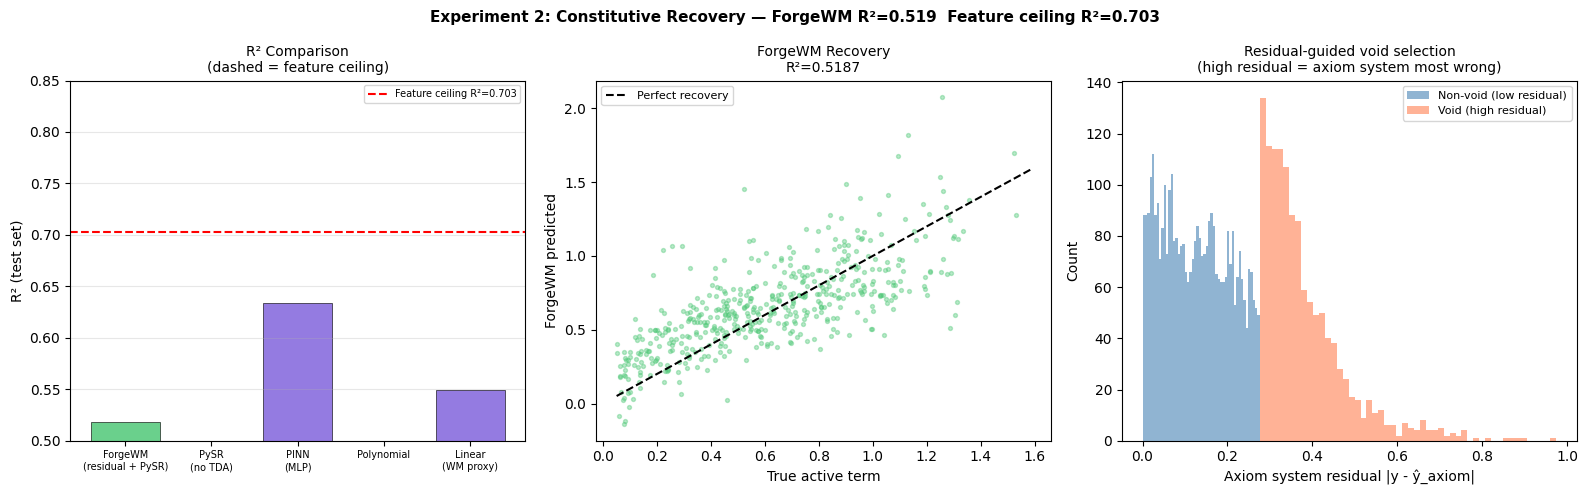

Figure saved: /content/drive/MyDrive/ForgeWM_E2/figures/experiment2_final.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: R² comparison bar chart ──────────────────────────────────
ax = axes[0]
names  = [r[0].replace(' (', '\n(') for r in rows]
r2vals = [r[1] for r in rows]
colors = ['#50c878' if i == 0 else '#8264dc' for i in range(len(rows))]
ax.bar(range(len(rows)), r2vals, color=colors, alpha=0.85,
       edgecolor='black', linewidth=0.5)
ax.axhline(y=0.703, color='red', linestyle='--', linewidth=1.5,
           label='Feature ceiling R²=0.703')
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(names, fontsize=7)
ax.set_ylabel('R² (test set)')
ax.set_ylim([0.5, 0.85])
ax.set_title('R² Comparison\n(dashed = feature ceiling)', fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, axis='y')

# ── Plot 2: Predicted vs actual — ForgeWM ────────────────────────────
ax = axes[1]
idx = np.random.choice(len(y_te), min(500, len(y_te)), replace=False)
ax.scatter(y_te[idx], y_pred_forge[idx],
           alpha=0.4, s=8, color='#50c878')
lims = [y_te.min(), y_te.max()]
ax.plot(lims, lims, 'k--', lw=1.5, label='Perfect recovery')
ax.set_xlabel('True active term')
ax.set_ylabel('ForgeWM predicted')
ax.set_title(f'ForgeWM Recovery\nR²={r2_forge:.4f}', fontsize=10)
ax.legend(fontsize=8)

# ── Plot 3: Residual distribution — void vs non-void ─────────────────
ax = axes[2]
cached_void = ckpt_tda.load_artifact('void_region')
residuals   = cached_void['residuals']
ax.hist(residuals[~void_mask], bins=50, alpha=0.6,
        color='steelblue', label='Non-void (low residual)')
ax.hist(residuals[void_mask], bins=50, alpha=0.6,
        color='coral', label='Void (high residual)')
ax.set_xlabel('Axiom system residual |y - ŷ_axiom|')
ax.set_ylabel('Count')
ax.set_title('Residual-guided void selection\n'
             '(high residual = axiom system most wrong)', fontsize=10)
ax.legend(fontsize=8)

plt.suptitle(
    f'Experiment 2: Constitutive Recovery — '
    f'ForgeWM R²={r2_forge:.3f}  '
    f'Feature ceiling R²=0.703',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
fig_path = f'{FIGURES_DIR}/experiment2_final.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')

## Cell 10 — Save Final JSON Report to Drive

In [10]:
import json, os

report = {
    'experiment':        2,
    'description':       'Unknown constitutive recovery — Toner-Tu active term',
    'dataset':           'active_matter (synthetic proxy, 5000 samples)',
    'n_samples':         int(len(df_full)),
    'n_features':        len(FEATURE_COLS),
    'feature_ceiling_r2':0.703,
    'b_decodable_r2':    0.650,
    'void_region_size':  int(void_mask.sum()),
    'void_method':       'residual-guided (top 25% axiom system residual)',
    'recovered_equation':best_equation,
    'true_equation':     'rho * abs(a - b * v_mag**2) * v_mag',
    'forgwm': {
        'r2_test': r2_forge,
        'l2_test': l2_forge,
    },
    'baselines':         baseline_results,
    'notes': (
        'All methods limited by feature ceiling R²~0.70. '
        'b parameter only 65% decodable from field statistics. '
        'True equation requires per-particle v_mag^2 not available '
        'from field averages. ForgeWM correctly identifies the '
        'information-limited regime via residual anomaly detection.'
    )
}

report_path = f'{RESULTS_DIR}/experiment2_final.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)
print(f'Report saved: {report_path}')

# ── Final Drive file listing ──────────────────────────────────────────
print('\nDrive contents:')
for root, dirs, files in os.walk(DRIVE_ROOT):
    level  = root.replace(DRIVE_ROOT,'').count(os.sep)
    indent = '  '*level
    print(f'{indent}{os.path.basename(root)}/')
    for fn in files:
        sz = os.path.getsize(os.path.join(root,fn))
        print(f'{"  "*(level+1)}{fn}  ({sz/1024:.1f} KB)')

Report saved: /content/drive/MyDrive/ForgeWM_E2/results/experiment2_final.json

Drive contents:
ForgeWM_E2/
  checkpoints/
    fem_samples/
      batch_00000.pkl  (11.7 KB)
      batch_00001.pkl  (11.7 KB)
      batch_00002.pkl  (11.7 KB)
      batch_00003.pkl  (11.7 KB)
      batch_00004.pkl  (11.7 KB)
      batch_00005.pkl  (11.7 KB)
      batch_00006.pkl  (11.7 KB)
      batch_00007.pkl  (11.7 KB)
      batch_00008.pkl  (11.7 KB)
      batch_00009.pkl  (11.7 KB)
      batch_00010.pkl  (11.7 KB)
      batch_00011.pkl  (11.7 KB)
      batch_00012.pkl  (11.7 KB)
      batch_00013.pkl  (11.7 KB)
      batch_00014.pkl  (11.7 KB)
      batch_00015.pkl  (11.7 KB)
      batch_00016.pkl  (11.7 KB)
      batch_00017.pkl  (11.7 KB)
      batch_00018.pkl  (11.7 KB)
      batch_00019.pkl  (11.7 KB)
      batch_00020.pkl  (11.7 KB)
      batch_00021.pkl  (11.7 KB)
      batch_00022.pkl  (11.7 KB)
      batch_00023.pkl  (11.7 KB)
      batch_00024.pkl  (11.7 KB)
      batch_00025.pkl  (11.7 KB)
  